In [11]:
import pandas as pd
import numpy as np
import re
import tldextract
import requests
import whois
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

In [12]:
df = pd.read_csv("../data/urldata.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (450176, 4)
   Unnamed: 0                        url   label  result
0           0     https://www.google.com  benign       0
1           1    https://www.youtube.com  benign       0
2           2   https://www.facebook.com  benign       0
3           3      https://www.baidu.com  benign       0
4           4  https://www.wikipedia.org  benign       0


In [ ]:

df = df.drop(columns=['Unnamed: 0', 'result'])


df['label'] = df['label'].map({
    'benign': 0,
    'malicious': 1
})

print(df['label'].value_counts())

label
0    345738
1    104438
Name: count, dtype: int64


In [ ]:

df_final = df.copy()


df_final = df_final[df_final['url'].notna()]


df_final['url'] = df_final['url'].astype(str)

print("Shape after cleaning:", df_final.shape)

Shape after cleaning: (450176, 2)


In [ ]:
import re
import tldextract
import math
from urllib.parse import urlparse

def entropy(s):
    prob = [float(s.count(c)) / len(s) for c in dict.fromkeys(list(s))]
    return -sum([p * math.log2(p) for p in prob])

def extract_features(url):
    try:
        url = str(url)
        if not url.startswith("http"):
            url = "http://" + url

        parsed = urlparse(url)
        ext = tldextract.extract(url)

        features = {}

        
        features['url_length'] = len(url)
        features['hostname_length'] = len(parsed.netloc)
        features['path_length'] = len(parsed.path)

        
        features['num_digits'] = sum(c.isdigit() for c in url)
        features['num_special_chars'] = sum(c in "@#$%^&*()-_=+[]{}|;:,.<>?" for c in url)
        features['num_dots'] = url.count('.')
        features['num_hyphens'] = url.count('-')

        
        features['num_subdomains'] = len(ext.subdomain.split('.')) if ext.subdomain else 0
        features['has_https'] = int(parsed.scheme == 'https')
        features['has_ip'] = int(bool(re.search(r'\d+\.\d+\.\d+\.\d+', url)))

        
        features['has_at'] = int('@' in url)
        features['has_suspicious_words'] = int(any(w in url.lower() for w in ['login','verify','bank','secure']))

        
        features['url_entropy'] = entropy(url)
        features['domain_length'] = len(ext.domain)
        features['tld_length'] = len(ext.suffix)

        return features

    except:
        return {k:0 for k in [
            'url_length','hostname_length','path_length',
            'num_digits','num_special_chars','num_dots','num_hyphens',
            'num_subdomains','has_https','has_ip','has_at',
            'has_suspicious_words','url_entropy','domain_length','tld_length'
        ]}

In [42]:
feature_list = df_final['url'].apply(extract_features)

X = pd.DataFrame(feature_list.tolist())
y = df_final['label']

print("Features shape:", X.shape)

Features shape: (450176, 15)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (360140, 15)
Test: (90036, 15)


In [44]:
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print("scale_pos_weight:", scale)

scale_pos_weight: 3.3104727707959305


In [45]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [ ]:
y_probs = model.predict_proba(X_test)[:,1]


y_pred = (y_probs > 0.7).astype(int)

In [47]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.997078946199298

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     69148
           1       1.00      0.99      0.99     20888

    accuracy                           1.00     90036
   macro avg       1.00      0.99      1.00     90036
weighted avg       1.00      1.00      1.00     90036



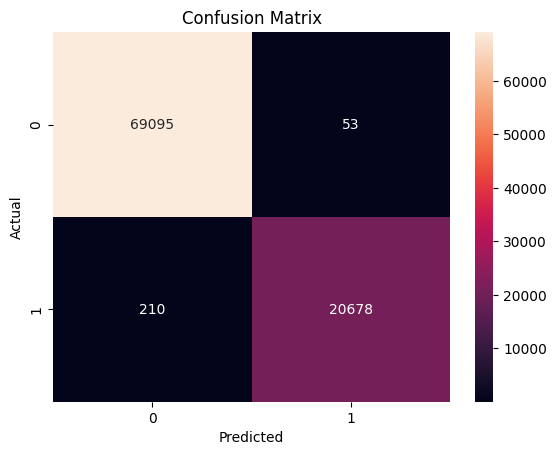

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
import joblib

joblib.dump(model, "xgboost_phishing_model.pkl")
print("Model saved ✅")

Model saved ✅


In [ ]:
def predict_url(url):
    features = extract_features(url)
    df = pd.DataFrame([features])
    
    prob = model.predict_proba(df)[0][1]
    
    if prob > 0.7:
        return "Phishing", prob
    else:
        return "Benign", prob


print(predict_url("https://github.com/"))
print(predict_url("https://ibapam.in/"))

('Benign', np.float32(0.24222177))
('Phishing', np.float32(0.98098844))
